# Исследовательский анализ данных  Яндекс Афиши 

- Автор: Захаров Максим
- Дата: 13.04.26

### Цели и задачи проекта:

**Цель проекта:**  провести исследовательский анализ данных и проверить гипотезы.

**Задачи:**
1. Загрузить данные и познакомитьс с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных: 
4. Сформулировать выводы по проведенному анализу.

**Данные:**

Для анализа поступили данные сервиса **Яндекс Афиша** на период с 1 июня - 31 октября 2024 года

Данные состоят из 3-x датасетов:

1. `final_tickets_orders_df` - содержит информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных.

2. `final_tickets_events_df` - содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.
3. `final_tickets_tenge_df.csv` - содержит информацию курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге.

### Описание датасета `final_tickets_orders_df.csv` :

- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.

### Описание датасета `final_tickets_events_df` :

- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

### Описание датасета `final_tickets_tenge_df.csv`

- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).


### Содержимое проекта:
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных. 
4. Итоговые выводы.



## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Загружаем все данные из датасетов:
# Первый датасет:
final_tickets_orders_df= pd.read_csv('/datasets/final_tickets_orders_df.csv') 
# Второй датасет:
final_tickets_events_df=pd.read_csv('/datasets/final_tickets_events_df.csv')
# Третий датасет: 
final_tickets_tenge_df = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

-  Познакомимся с данными и получим общую информацию о них

Познакомимся с данными датасета `final_tickets_orders_df` Выведем первые строчки методом `head()`, а информацию о датафрейме методом `info()`

In [3]:
final_tickets_orders_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
final_tickets_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [5]:
# Проверяем данные на наличие пропусков в датафрейме final_tickets_orders_df :
final_tickets_orders_df.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

Датасет `final_tickets_orders_df` содержит 14 столбцов и 290849 строк, в которых представлена информация о заказах билетов, совершённых с двух типов устройств — мобильных и стационарных.
- Названия столбцов приведены к стилю snake_case и не требуют изменений.
- Типы данных:
`created_dt_msk` - object(Нужно изменить на тип date т.к это дата создания заказа)  
`created_ts_msk` - object(Нужно изменить на тип timestamp т.к это дата и время создания заказа) 
`days_since_prev` - float64( Тип данных корректный, тк пропуски в int не остаются) 
Размерность в столбцах `order_id` и `event_id` не понимажем,поскольку хранятся важные данные для анализа.
- В данных встречаются пропуски только в столбце `days_since_prev` -  столбец не редактируем.



Теперь познакомимся с данными второго датасета: `final_tickets_events_df`

In [6]:
final_tickets_events_df.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [7]:
final_tickets_events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [8]:
# Проверяем данные на наличие пропусков в датафрейме final_tickets_events_df :
final_tickets_events_df.isna().sum()

event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

Датасет `final_tickets_events_df` содержит 11 столбцов и 22427 строк, хранящих информацию о о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. 

- Названия столбцов приведены к стилю snake_case и не требуют изменений.
- Типы данных: Все типа данных присвоены верно, в корректировке не нуждаются. 
- Пропуски отсутствуют.


Теперь познакомимся с данными третьего датасета: `final_tickets_tenge_df`

In [9]:
final_tickets_tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
final_tickets_tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [11]:
# Проверяем данные на наличие пропусков в датафрейме final_tickets_tenge_df :
final_tickets_tenge_df.isna().sum()

data       0
nominal    0
curs       0
cdx        0
dtype: int64

Датасет `final_tickets_tenge_df` содержит 4 столбца и 357 строк,которые содержат информацию о курсе тенге к российскому рублю за 2024 год. 
-Названия столбцов корректны.
- Типы данных:
1. data нужно изменить тип данных с object на date, так как данные содрежат информацию о дате.
2. Во всех остальных столбцах тип данных присвоен верно.
- Пропуски отсутствуют.


В данных трех датасетов отсуттвуют пропуски, кроме столбца `days_since_prev`.
Выгрузка данных из SQL была успешной.

##  2. Предобработка данных

2.1 Изучаем значения в ключевых столбцах

In [12]:
# 1 Изучим, какие категории присутствуют в данных:
categorial_columns = final_tickets_orders_df.select_dtypes(include=['object']).columns

print(categorial_columns)

Index(['user_id', 'created_dt_msk', 'created_ts_msk', 'cinema_circuit',
       'currency_code', 'device_type_canonical', 'service_name'],
      dtype='object')


In [13]:
# 2 Проверяем, встречаются ли значения, которые могут обозначать пропуски в данных или отсутствие информации:
for col in categorial_columns:
    print(f"{col}")
    print(final_tickets_orders_df[col].unique()[:10])

user_id
['0002849b70a3ce2' '0005ca5e93f2cf4' '000898990054619' '00096d1f542ab2b'
 '000a55a418c128c' '000cf0659a9f40f' '00147c9209d45d3' '0018ecd8a38a51b'
 '00199a573901564' '001e7037d013f0f']
created_dt_msk
['2024-08-20' '2024-07-23' '2024-10-06' '2024-07-13' '2024-10-04'
 '2024-10-23' '2024-08-15' '2024-09-29' '2024-10-15' '2024-06-20']
created_ts_msk
['2024-08-20 16:08:03' '2024-07-23 18:36:24' '2024-10-06 13:56:02'
 '2024-07-13 19:40:48' '2024-10-04 22:33:15' '2024-10-23 15:12:00'
 '2024-08-15 16:48:48' '2024-09-29 19:39:12' '2024-10-15 10:29:04'
 '2024-06-20 10:35:26']
cinema_circuit
['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
currency_code
['rub' 'kzt']
device_type_canonical
['mobile' 'desktop']
service_name
['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры']


Пропусков в данных нет,информация полная. Данные корректы,нормализация не требуется. 

Для количественных значений посмотрим на распределение и наличие выбросов. 


In [14]:
# 1 Разделим валюты на рублю и тенге:
rub_code=final_tickets_orders_df[final_tickets_orders_df['currency_code'] == 'rub']
kzt_code=final_tickets_orders_df[final_tickets_orders_df['currency_code'] == 'kzt']

#Проверяем результат:
print(f"Заказы в рублях: {len(rub_code)}")
print(f"Заказы в тенге: {len(kzt_code)}")

Заказы в рублях: 285780
Заказы в тенге: 5069


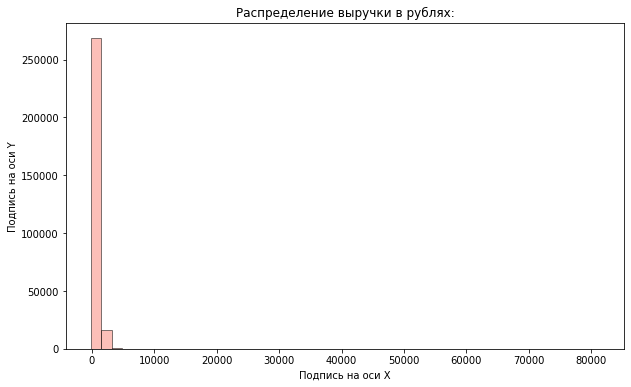

In [15]:
# 2 С помощью гистограммы распредедния посмотрим на распределение и выбросы в рублях:

plt.figure(figsize=(10,6))
plt.hist(rub_code['revenue'],bins=50,
        alpha=0.5,color='salmon',edgecolor='black')
plt.xlabel('Подпись на оси X')
plt.ylabel('Подпись на оси Y')
plt.title('Распределение выручки в рублях:')
plt.show()

In [16]:
# Вывожу на экран детальные данные по рублю:
print(rub_code['revenue'].describe())
print(f" \n 99-перцентель: {rub_code['revenue'].quantile(0.99)}")

count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64
 
 99-перцентель: 2569.5942000000005


In [17]:
# Убираем отрицательную выручку:
rub_count_positive = rub_code[rub_code['revenue'] >=0]

# Находим 99-перцентель на отобранных данных:
rub_code_99_quantile = rub_count_positive['revenue'].quantile(0.99)

# Отбираем значения по 99-перцентель:
rub_code_clean= rub_count_positive[rub_count_positive['revenue'] <=rub_code_99_quantile]

#Проверяем:
print(f"Исходные заказы в рублях: {len(rub_code)}")
print(f"Данные после удаления отрицательной выручки: {len(rub_count_positive)}")
print(f"Данные после удаления выбросов: {len(rub_code_clean)}")

Исходные заказы в рублях: 285780
Данные после удаления отрицательной выручки: 285399
Данные после удаления выбросов: 282599


Удалено 3181 выбросов

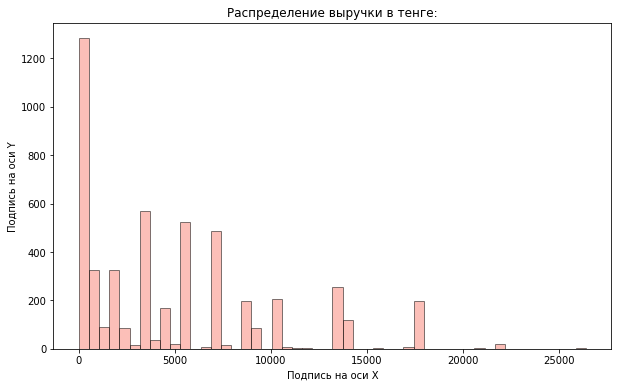

In [18]:
# 2 С помощью гистограммы распредедния посмотрим на распределение и выбросы в тенге:

plt.figure(figsize=(10,6))
plt.hist(kzt_code['revenue'],bins=50,
        alpha=0.5,color='salmon',edgecolor='black')
plt.xlabel('Подпись на оси X')
plt.ylabel('Подпись на оси Y')
plt.title('Распределение выручки в тенге:')
plt.show()

In [19]:
# Вывожу на экран детальные данные по тенге:
print(kzt_code['revenue'].describe())
print(f" \n 99-перцентель: {kzt_code['revenue'].quantile(0.99)}")

count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64
 
 99-перцентель: 17617.24


In [20]:
# Убираем отрицательную выручку:
kzt_code_positive = kzt_code[kzt_code['revenue'] >=0]

# Находим 99-перцентель на отобранных данных:
kzt_code_99_quantile = kzt_code_positive['revenue'].quantile(0.99)

# Отбираем значения по 99-перцентель:
kzt_code_clean= kzt_code_positive[kzt_code_positive['revenue'] <=kzt_code_99_quantile]

#Проверяем:
print(f"Исходные заказы в тенге: {len(kzt_code)}")
print(f"Данные после удаления отрицательной выручки: {len(kzt_code_positive)}")
print(f"Данные после удаления выбросов: {len(kzt_code_clean)}")

Исходные заказы в тенге: 5069
Данные после удаления отрицательной выручки: 5069
Данные после удаления выбросов: 5040


Удалено 29 выбросов

Теперь переходим к проверки столбца с билетами `tickets_count`

In [21]:
print(final_tickets_orders_df['tickets_count'].describe())

count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


Данные в столбце `tickets_count` чистые, нет нулей или отрицательных значений. 
В среднем покупают 2-4 билета
Данные готовы для дальнейшего анализа.

Проверяем данные на явные и невяные дупликаты

In [22]:
# Проверяем полные дубликаты в датафрейме final_tickets_orders_df
final_tickets_orders_df.duplicated().sum()

0

In [23]:
# Проверяем полные дубликаты в датафрейме final_tickets_events_df
final_tickets_events_df.duplicated().sum()

0

In [24]:
# Проверяем полные дубликаты в датафрейме final_tickets_tenge_df.csv
final_tickets_tenge_df.duplicated().sum()

0

Явные дупликаты не найдены,поэтому переходим к поиску неявных дупликатов:
    

In [25]:
# Выбираем колонки для проверки:
columns_to_check = ['user_id','created_dt_msk','event_id']

# Находим дупликаты:
duplicates = final_tickets_orders_df[final_tickets_orders_df.duplicated(subset=columns_to_check,keep=False)]

# Проверяем:
print(f"Найдено дупликатов:{len(duplicates)}")

# Выведем на экран дупликаты:
real_duplicates = final_tickets_orders_df.duplicated(subset=['user_id', 'event_id', 'created_ts_msk'], keep=False).sum()
print(f"Настоящих дубликатов с одинаковым временем: {real_duplicates}")

# Найденные дупликаты выводим на экран:
real_duplicates_show= final_tickets_orders_df[final_tickets_orders_df.duplicated(subset=['user_id', 'event_id', 'created_ts_msk'],keep=False)]

real_duplicates_show

Найдено дупликатов:144803
Настоящих дубликатов с одинаковым временем: 225


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
4358,1158638,02ea4583333f064,2024-08-23,2024-08-23 22:46:05,540072,нет,12,rub,mobile,89.61,Билеты в руки,3,995.67,0.0
4359,1158696,02ea4583333f064,2024-08-23,2024-08-23 22:46:05,540072,нет,12,rub,mobile,59.74,Билеты в руки,2,663.78,0.0
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
12696,5593202,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,mobile,0.00,Билеты без проблем,3,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285622,8547867,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,Билеты без проблем,4,14660.31,0.0
286200,6201419,fd4d47438ebb946,2024-09-23,2024-09-23 16:26:42,560819,нет,16,rub,mobile,48.73,Мой билет,2,1624.40,0.0
286203,6201361,fd4d47438ebb946,2024-09-23,2024-09-23 16:26:42,560819,нет,16,rub,mobile,24.37,Мой билет,1,812.20,0.0
289543,2376638,fe237d2cfd6e503,2024-10-31,2024-10-31 22:28:47,589624,нет,16,rub,desktop,167.32,Мой билет,4,4183.01,0.0


В датафрейме найдено 225 дупликатов по полям `user_id`, `created_ts_msk	`,`order_id	` ,такое явление может быть связано с особенностью системы/багом в системе/поведенеием пользователя, поскольку клиент может оформлять 2 заказа в одно и тоже время. Такие заказы мы не удаляем, поскольку кол-во билетов может быть разным.

In [26]:
# Неявные дубликаты событий в final_tickets_events_df
dups_events = final_tickets_events_df[final_tickets_events_df.duplicated(subset=['event_name', 'city_name', 'venue_name'], keep=False)]
print(f"Неявных дубликатов в final_tickets_events_df: {len(dups_events)}")

# Выводим на экран чтобы увидеть полную картину:
dups_events.head(10)

Неявных дубликатов в final_tickets_events_df: 2256


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11,10001,141cc2fd-c694-48a8-8356-927b35e9a61f,спектакль,театр,№1691,Травяная область,Родниковск,22,2355,"Театр молодежи ""Забавный"" Групп","пр. Фрунзе, д. 454 стр. 160"
13,10015,6a9aae29-36ef-4d01-b717-90b4bfbb1338,спектакль,театр,№1691,Травяная область,Родниковск,22,2355,"Театр молодежи ""Забавный"" Групп","пр. Фрунзе, д. 454 стр. 160"
22,10154,c66dd4ac-a8a5-453b-a647-deed11adcef6,спектакль,театр,№3529,Серебринская область,Озёрчане,62,3149,"Дворец культуры ""Скворечник"" Инк","пер. Кочубея, д. 7/7 к. 50"
44,10356,c7282129-4a7a-44d0-bac1-a2d652faedb5,мюзикл,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
98,10837,eb6fc70b-7884-41d4-8da8-11bdc1efb9e4,балет,театр,№1714,Широковская область,Радужнополье,35,3149,"Дворец культуры ""Скворечник"" Инк","пер. Кочубея, д. 7/7 к. 50"
102,10912,c8a6858d-1594-42d6-851c-c580dd621675,спектакль,театр,№1037,Горицветская область,Островецк,50,3896,"Заповедник ""Ода"" и партнеры","ул. Ленская, д. 1/6 к. 2"
103,10914,20be7743-67f2-4ffc-88e3-4486ee3c2829,спектакль,театр,№1037,Горицветская область,Островецк,50,3896,"Заповедник ""Ода"" и партнеры","ул. Ленская, д. 1/6 к. 2"
159,11311,0714435e-3b5f-4312-aa36-c3a9d8853ef4,балет,театр,№4618,Североярская область,Озёрск,2,4601,"Молодежная творческая группа ""Лебедь"" и партнеры","бул. Волочаевский, д. 9/5"
220,11612,109b3888-8028-483d-9560-7f77320642e2,балет,театр,№4366,Каменевский регион,Глиногорск,213,3565,"Культурно-досуговый центр ""Детскость"" Групп","пер. Курортный, д. 3/6 стр. 67"
228,11674,0714435e-3b5f-4312-aa36-c3a9d8853ef4,балет,театр,№4366,Каменевский регион,Глиногорск,213,3565,"Культурно-досуговый центр ""Детскость"" Групп","пер. Курортный, д. 3/6 стр. 67"


В датафрейме `final_tickets_events_df` найдено 2256 неявных дупликатов. Это не дупликаты, а разные события,которые могут происходить на одной площадке в одном городе.
Удаление дупликатов не требуется.

In [27]:
# Неявные дубликаты событий в final_tickets_tenge_df
dups_tenge = final_tickets_tenge_df[final_tickets_tenge_df.duplicated(subset=['data','curs'], keep=False)]
print(f"Неявных дубликатов в final_tickets_tenge_df: {len(dups_tenge)}")

Неявных дубликатов в final_tickets_tenge_df: 0


Преобразовываем типы данных. 

In [28]:
# 1 Преобразовываем типы данных в датасете final_tickets_orders_df
final_tickets_orders_df['created_dt_msk']=pd.to_datetime(final_tickets_orders_df['created_dt_msk'])
final_tickets_orders_df['created_ts_msk']=pd.to_datetime(final_tickets_orders_df['created_ts_msk'])

# Проверяем результат:
print(final_tickets_orders_df[['created_dt_msk','created_ts_msk']].dtypes)

created_dt_msk    datetime64[ns]
created_ts_msk    datetime64[ns]
dtype: object


Понижаем размерность данных

In [29]:
# Выводим на экран типы данных:
print(final_tickets_orders_df.dtypes)

order_id                          int64
user_id                          object
created_dt_msk           datetime64[ns]
created_ts_msk           datetime64[ns]
event_id                          int64
cinema_circuit                   object
age_limit                         int64
currency_code                    object
device_type_canonical            object
revenue                         float64
service_name                     object
tickets_count                     int64
total                           float64
days_since_prev                 float64
dtype: object


In [30]:
# age_limit - маленькие числа int8 , revenue - нужна невысокая точность float32, tickets_count - маленькие числа int8,total - нужна невысокая точность float32
final_tickets_orders_df['age_limit'] = final_tickets_orders_df['age_limit'].astype('int8')
final_tickets_orders_df['revenue'] = final_tickets_orders_df['revenue'].astype('float32')
final_tickets_orders_df['tickets_count'] = final_tickets_orders_df['tickets_count'].astype('int8')
final_tickets_orders_df['total'] = final_tickets_orders_df['total'].astype('float32')
# Проверяем результат: 
print(final_tickets_orders_df.dtypes)

order_id                          int64
user_id                          object
created_dt_msk           datetime64[ns]
created_ts_msk           datetime64[ns]
event_id                          int64
cinema_circuit                   object
age_limit                          int8
currency_code                    object
device_type_canonical            object
revenue                         float32
service_name                     object
tickets_count                      int8
total                           float32
days_since_prev                 float64
dtype: object


Создаем несколько новых столбцов:

In [31]:
# 1  Приводим дату в tenge_df к datetime
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

# 2 Создаем столбец kurs
final_tickets_tenge_df['kurs'] = final_tickets_tenge_df['curs'] / 100

# 3  Добавляем курс к заказам 
final_tickets_orders_df = final_tickets_orders_df.merge(
    final_tickets_tenge_df[['data', 'kurs']],  
    left_on='created_dt_msk',
    right_on='data',
    how='left'
)

# 4 Создаем revenue_rub
final_tickets_orders_df['revenue_rub'] = final_tickets_orders_df['revenue']

# 5  Для тенге пересчитываем
final_tickets_orders_df.loc[final_tickets_orders_df['currency_code'] == 'kzt', 'revenue_rub'] = final_tickets_orders_df['revenue'] * final_tickets_orders_df['kurs']

# 6 Выручка на 1 билет
final_tickets_orders_df['one_ticket_revenue_rub'] = final_tickets_orders_df['revenue_rub'] / final_tickets_orders_df['tickets_count']

# 7 Месяц
final_tickets_orders_df['month'] = final_tickets_orders_df['created_dt_msk'].dt.month

# 8 Сезон
final_tickets_orders_df['season'] = final_tickets_orders_df['month'].map({1:'зима',2:'зима',3:'весна',4:'весна',5:'весна',6:'лето',7:'лето',8:'лето',9:'осень',10:'осень',11:'осень',12:'зима'})

# 9 Проверяем
final_tickets_orders_df[['currency_code', 'revenue', 'kurs', 'revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].head(10)

,currency_code,revenue,kurs,revenue_rub,one_ticket_revenue_rub,month,season
0,rub,1521.939941,0.186972,1521.939941,380.484985,8,лето
1,rub,289.450012,0.183419,289.450012,144.725006,7,лето
2,rub,1258.569946,0.196475,1258.569946,314.642487,10,осень
3,rub,8.490000,0.185010,8.490000,4.245000,7,лето
4,rub,1390.410034,0.196648,1390.410034,463.470001,10,осень
5,rub,902.739990,0.200531,902.739990,300.913330,10,осень
6,rub,917.830017,0.187730,917.830017,229.457504,8,лето
7,rub,47.779999,0.193741,47.779999,47.779999,9,осень
8,rub,74.839996,0.197185,74.839996,37.419998,10,осень
9,rub,1421.910034,0.180419,1421.910034,355.477509,6,лето


In [32]:
# Проверяем заказы с тенге:
final_tickets_orders_df[final_tickets_orders_df['currency_code'] == 'kzt'][['currency_code', 'revenue', 'kurs', 'revenue_rub', 'one_ticket_revenue_rub']].head(10)

,currency_code,revenue,kurs,revenue_rub,one_ticket_revenue_rub
73,kzt,518.099976,0.190125,98.503761,24.625940
92,kzt,347.179993,0.189330,65.731590,21.910530
99,kzt,328.769989,0.185991,61.148258,15.287065
289,kzt,22021.550781,0.198928,4380.703125,876.140625
472,kzt,7397.660156,0.199833,1478.296631,369.574158
473,kzt,3698.830078,0.199833,739.148315,369.574158
474,kzt,7397.660156,0.199833,1478.296631,369.574158
475,kzt,5548.240234,0.199833,1108.721436,369.573822
476,kzt,7397.660156,0.199833,1478.296631,369.574158
528,kzt,361.079987,0.184217,66.517075,16.629269


В ходе предобработки данных мы:

    - Оставили пропуски в столбце `days_since_prev`,тк данные понадобятся для дальнейшего анализа.
    
    - В `created_ts_msk` и `created_dt_msk` изменили тип данных datetime,снизили размерность у следующих столбцов: `age_limit` - маленькие числа int8 , `revenue` - нужна невысокая точность float32, `tickets_count` - маленькие числа int8,`total` - нужна невысокая точность float32. 
    
    - Выбросы - удалили заказы с выручкой выше 99 перцентеля
    
    - Дубликаты - явных нет,неявные оставили,могут быть разные заказы.
    
    - Скрытых пропусков нет,нормализация не потребовалась. 

     Данные готовы для дальнейшего анализа.

##  3. Исследовательский анализ данных

### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

In [33]:
#  3.1.1  1 Для каждого месяца найдем количество заказов:
month_by_orders = final_tickets_orders_df.groupby('month').size().reset_index(name='orders_count')

# Проверяем результат:
print(month_by_orders)

   month  orders_count
0      6         34683
1      7         40925
2      8         45044
3      9         69976
4     10        100221


In [34]:
# Проверяем, есть ли в данных ноябрь:
print(final_tickets_orders_df['month'].value_counts().sort_index())

6      34683
7      40925
8      45044
9      69976
10    100221
Name: month, dtype: int64


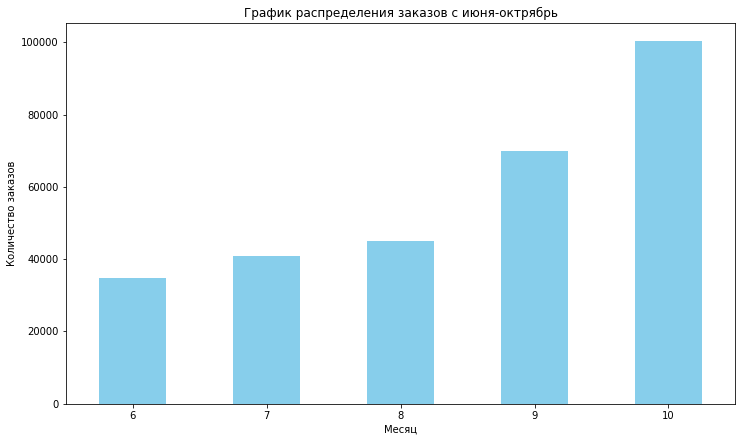

In [35]:
# Визуализируем полученные данные: (столбчатая диаграмма)
plt.figure(figsize=(12,7))
final_tickets_orders_df['month'].value_counts().sort_index().plot(
kind='bar',
title='График распределения заказов с июня-октрябрь',
legend=False,
xlabel='Месяц',
ylabel='Количество заказов',
rot=0,
color='skyblue',
)
plt.show()

По данным графика видно, что колличество заказов от июня к октябрю увеличивается 

In [36]:
# 3.1.2  Создаем 2 фильтра для сезонов: осень и лето

# Фильтр для сезона Осень:

autumn_season = final_tickets_orders_df[final_tickets_orders_df['month'].isin([9,10,11])]
                                       
# Фильтр для сезона Лето: 
summer_season = final_tickets_orders_df[final_tickets_orders_df['month'].isin([6,7,8])]
 
# Проверяем результат:
print(f"Осенние заказы: {len(autumn_season)}")         
print(f"Летние заказы: {len(summer_season)}")

Осенние заказы: 170197
Летние заказы: 120652


In [37]:
# Посчитаем тип мероприятия:
autumn_and_event = autumn_season.merge(final_tickets_events_df[['event_id','event_type_main']],on ='event_id',how = 'inner')
summer_and_event = summer_season.merge(final_tickets_events_df[['event_id','event_type_main']],on ='event_id',how = 'inner')

event_autumn =  autumn_and_event['event_type_main'].value_counts(normalize=True)*100
event_summer = summer_and_event['event_type_main'].value_counts(normalize=True)*100

# Проверяем результат:
print(f"Осень")
print(event_autumn.head())
print(f"Лето")
print(event_summer.head())

Осень
концерты    37.453798
театр       25.330395
другое      19.563391
спорт       11.105039
стендап      4.108712
Name: event_type_main, dtype: float64
Лето
концерты    42.793683
другое      27.047561
театр       20.106114
стендап      5.314856
спорт        2.501744
Name: event_type_main, dtype: float64


In [38]:
# Проверяем данные на наличие потери:
print(f"Осенью заказов было: {len(autumn_season)}, стало: {len(autumn_and_event)}")
print(f"Летом заказов было: {len(summer_season)}, стало: {len(summer_and_event)}")

# Проверяем на наличие пропусков
print(f"Пропуски в осенних данных: {autumn_and_event['event_type_main'].isna().sum()}")
print(f"Пропуски в летних данных: {summer_and_event['event_type_main'].isna().sum()}")


Осенью заказов было: 170197, стало: 170175
Летом заказов было: 120652, стало: 120436
Пропуски в осенних данных: 0
Пропуски в летних данных: 0


In [39]:
autumn_and_event.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,tickets_count,total,days_since_prev,data,kurs,revenue_rub,one_ticket_revenue_rub,month,season,event_type_main
0,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,...,4,13984.160156,75.0,2024-10-06,0.196475,1258.569946,314.642487,10,осень,другое
1,4710036,095aa77d7f92e81,2024-10-23,2024-10-23 10:39:47,578454,нет,0,rub,mobile,1258.569946,...,4,13984.160156,1.0,2024-10-23,0.200531,1258.569946,314.642487,10,осень,другое
2,1196657,0beb8fc0c0a9ce1,2024-10-04,2024-10-04 12:53:09,578454,нет,0,rub,mobile,1258.569946,...,4,13984.160156,0.0,2024-10-04,0.196648,1258.569946,314.642487,10,осень,другое
3,4000261,0beb8fc0c0a9ce1,2024-10-05,2024-10-05 16:37:43,578454,нет,0,rub,mobile,629.289978,...,2,6992.080078,0.0,2024-10-05,0.196475,629.289978,314.644989,10,осень,другое
4,4810753,0beb8fc0c0a9ce1,2024-10-06,2024-10-06 08:55:50,578454,нет,0,rub,mobile,1573.219971,...,5,17480.189453,0.0,2024-10-06,0.196475,1573.219971,314.643982,10,осень,другое


In [40]:
summer_and_event.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,tickets_count,total,days_since_prev,data,kurs,revenue_rub,one_ticket_revenue_rub,month,season,event_type_main
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,4,10870.990234,NaN,2024-08-20,0.186972,1521.939941,380.484985,8,лето,театр
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.420044,...,5,13588.740234,0.0,2024-07-23,0.183419,1902.420044,380.484009,7,лето,театр
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.449951,...,3,8153.250000,0.0,2024-07-23,0.183419,1141.449951,380.483307,7,лето,театр
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.420044,...,5,13588.740234,0.0,2024-07-23,0.183419,1902.420044,380.484009,7,лето,театр
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.939941,...,4,10870.990234,0.0,2024-07-23,0.183419,1521.939941,380.484985,7,лето,театр


In [41]:
# Тип устройства:
autumn_device = autumn_season['device_type_canonical'].value_counts(normalize=True)*100
summer_device = summer_season['device_type_canonical'].value_counts(normalize=True)*100


# Проверяем результат:
print(f"Осень")
print(autumn_device.head())
print(f"Лето")
print(summer_device.head())

Осень
mobile     79.61715
desktop    20.38285
Name: device_type_canonical, dtype: float64
Лето
mobile     80.5399
desktop    19.4601
Name: device_type_canonical, dtype: float64


In [42]:
# Возрастной рейтинг:
age_autumn = autumn_season['age_limit'].value_counts(normalize=True)*100
age_summer = summer_season['age_limit'].value_counts(normalize=True)*100

# Проверяем результат:
print(f"Осень")
print(age_autumn)
print(f"Лето")
print(age_summer)

Осень
16    26.172612
0     23.426970
12    22.140813
6     17.744144
18    10.515461
Name: age_limit, dtype: float64
Лето
16    28.208401
12    20.616318
6     18.211882
0     17.915161
18    15.048238
Name: age_limit, dtype: float64


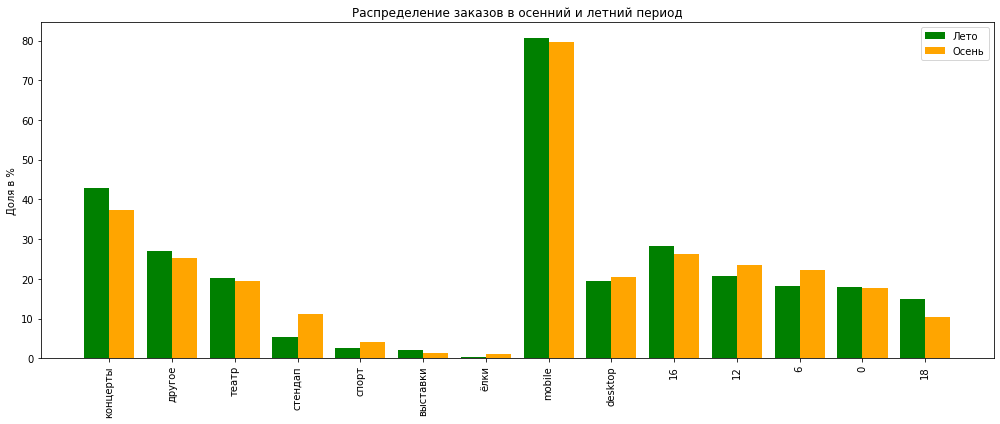

In [43]:
# Визуализируем данные на столбчатой диаграмме:

# Данные для визуализации:
categories = list(event_summer.index) + list(summer_device.index) + list(age_summer.index)

autumn = list(event_autumn.values) + list(autumn_device.values) + list(age_autumn.values)

summer = list(event_summer.values) + list(summer_device.values) + list(age_summer.values)

# График
x = range(len(categories))
plt.figure(figsize=(14, 6))
plt.bar([i - 0.2 for i in x], summer, 0.4, label='Лето', color='green')
plt.bar([i + 0.2 for i in x], autumn, 0.4, label='Осень', color='orange')
plt.xticks(x, categories, rotation=90)
plt.ylabel('Доля в %')
plt.title('Распределение заказов в осенний и летний период')
plt.legend()
plt.tight_layout()
plt.show()

В ходе сравнения показателей за лето и осень мы выяснили:

    - Заказы осенью по сравнению с летом выросли на 49 545
    
    - Тип мероприятия: летом доля концертов и категории другое была выше чем осенью. Доля спорта наоборот,выше осенью.
    
    - Тип устройства: 80% заказов совершается  в оба сезона с мобильного телефона.
    - Возрастной рейтинг: осенью выросла категория 12+ и 0+, категория 18+ снизилась.

In [44]:
# 3.1.3  Изучаем  изменение выручки с продажи одного билета:

# 1 Найдем среднюю выручку за билет:

# Лето:

summer_ticket = summer_season.merge(final_tickets_events_df[['event_id','event_type_main']])
summer_ticket = summer_ticket.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Осень:
autumn_ticket = autumn_season.merge(final_tickets_events_df[['event_id', 'event_type_main']])
autumn_ticket = autumn_ticket.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Проверяем результат: 
print(f"Лето")
print(summer_ticket)
print(f"Осень")
print(autumn_ticket)

Лето
event_type_main
выставки     86.388611
другое       81.091087
концерты    319.079895
спорт        54.112064
стендап     227.070679
театр       222.528473
ёлки        276.388214
Name: one_ticket_revenue_rub, dtype: float32
Осень
event_type_main
выставки     91.066620
другое       77.107788
концерты    286.757233
спорт        52.132324
стендап     249.963867
театр       183.047180
ёлки        234.503845
Name: one_ticket_revenue_rub, dtype: float32


In [45]:
# Среднее значение выручки с одного билета на осень ,
share = (autumn_ticket - summer_ticket ) /summer_ticket *100
print(share)

event_type_main
выставки     5.415076
другое      -4.912129
концерты   -10.129959
спорт       -3.658593
стендап     10.081966
театр      -17.742130
ёлки       -15.154180
Name: one_ticket_revenue_rub, dtype: float32


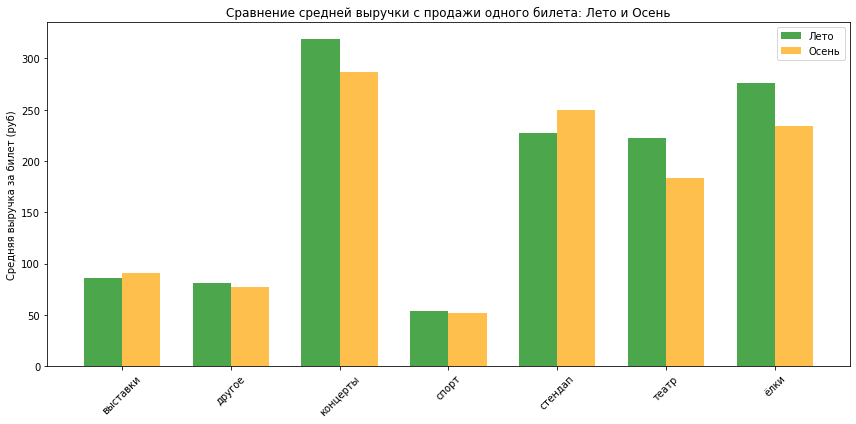

In [46]:
# График для сравнения средней выручки за билет (лето vs осень)
plt.figure(figsize=(12, 6))

# Получаем общий список категорий
categories = list(summer_ticket.index)

# Позиции для столбцов
x = range(len(categories))
width = 0.35

# Столбцы
plt.bar([i - width/2 for i in x], summer_ticket.values, width, label='Лето', color='green', alpha=0.7)
plt.bar([i + width/2 for i in x], autumn_ticket.values, width, label='Осень', color='orange', alpha=0.7)

# Настройки
plt.xticks(x, categories, rotation=45)
plt.ylabel('Средняя выручка за билет (руб)')
plt.title('Сравнение средней выручки с продажи одного билета: Лето и Осень')
plt.legend()
plt.tight_layout()
plt.show()

Самая высокая выручка за билет - лето: концерты (319 руб), ёлки (276 руб), стендап (227 руб)
    
Самая высокая выручка за билет - осень: концерты (286 руб), стендап (249 руб), ёлки (234 руб)

 Увеличение: Стандап к осени вырос на 10% и выставки на 5%
 
Снизились: другое на 4%,концерты на 10%,  спорт на 3%, театр на 17% и ёлки на 15%

Билеты подешевели везде,кроме стендапов и выставок.     

<Figure size 720x360 with 0 Axes>

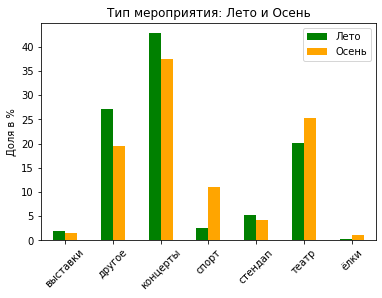

In [47]:
# Тип мероприятия
plt.figure(figsize=(10, 5))
event_comparison = pd.DataFrame({'Лето': event_summer, 'Осень': event_autumn})
event_comparison.plot(kind='bar', color=['green', 'orange'])
plt.title('Тип мероприятия: Лето и Осень')
plt.ylabel('Доля в %')
plt.xticks(rotation=45)
plt.show()

<Figure size 432x360 with 0 Axes>

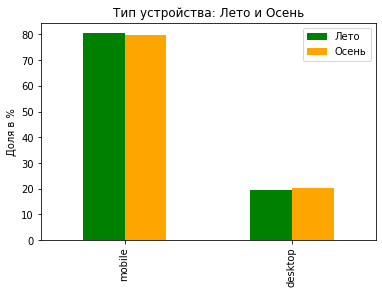

In [48]:
#  Тип устройства
plt.figure(figsize=(6, 5))
device_comparison = pd.DataFrame({'Лето': summer_device, 'Осень': autumn_device})
device_comparison.plot(kind='bar', color=['green', 'orange'])
plt.title('Тип устройства: Лето и Осень')
plt.ylabel('Доля в %')
plt.show()

<Figure size 576x360 with 0 Axes>

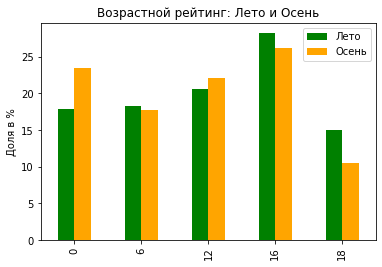

In [49]:
#  Возрастной рейтинг
plt.figure(figsize=(8, 5))
age_comparison = pd.DataFrame({'Лето': age_summer, 'Осень': age_autumn})
age_comparison.plot(kind='bar', color=['green', 'orange'])
plt.title('Возрастной рейтинг: Лето и Осень')
plt.ylabel('Доля в %')
plt.show()

Осенью выросла доля театров и спорта, билеты подешевели почти везде,кроме стендапов и выставок. Главный канал продаж - мобильные устройства

### 3.2. Осенняя активность пользователей

In [50]:
# 1 Отфильтруем данные за 2 осенних месяца:
autumn_data = final_tickets_orders_df[final_tickets_orders_df['month'].isin([9,10])].copy()


In [51]:
# 2 Находим общее колличество заказов по дням:
total_orders = autumn_data.groupby('created_dt_msk')['order_id'].count()
# Проверяем результат
print(total_orders.head(10))

created_dt_msk
2024-09-01    1348
2024-09-02    1391
2024-09-03    5124
2024-09-04    1785
2024-09-05    1960
2024-09-06    2151
2024-09-07    1979
2024-09-08    1724
2024-09-09    2112
2024-09-10    2038
Name: order_id, dtype: int64


In [52]:
# 3 Посчитаем количество активных пользователей DAU:
dau_users = autumn_data.groupby('created_dt_msk')['user_id'].nunique()
# Проверяем результат
print(dau_users.head())

created_dt_msk
2024-09-01    569
2024-09-02    580
2024-09-03    783
2024-09-04    688
2024-09-05    745
Name: user_id, dtype: int64


In [53]:
# 4 Посчитаем среднее число заказов на одного пользователя:
average_number_of_orders_per_user = total_orders / dau_users
print(average_number_of_orders_per_user.head())

created_dt_msk
2024-09-01    2.369069
2024-09-02    2.398276
2024-09-03    6.544061
2024-09-04    2.594477
2024-09-05    2.630872
dtype: float64


In [54]:
# 5 Посчитаем среднюю стоимость одного билета:
average_cost_of_one_ticket = autumn_data.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean()

print(average_cost_of_one_ticket.head())


created_dt_msk
2024-09-01    208.117508
2024-09-02    195.536087
2024-09-03     82.095428
2024-09-04    184.003357
2024-09-05    194.513168
Name: one_ticket_revenue_rub, dtype: float32


In [55]:
# Сводим все значения в одну сводную таблицу
summary = pd.DataFrame({
    'заказы': total_orders,
    'DAU': dau_users,
    'заказов_на_пользователя': average_number_of_orders_per_user,
    'цена_билета': average_cost_of_one_ticket
})

# Проверяем результат:
print(summary.head())

                заказы  DAU  заказов_на_пользователя  цена_билета
created_dt_msk                                                   
2024-09-01        1348  569                 2.369069   208.117508
2024-09-02        1391  580                 2.398276   195.536087
2024-09-03        5124  783                 6.544061    82.095428
2024-09-04        1785  688                 2.594477   184.003357
2024-09-05        1960  745                 2.630872   194.513168


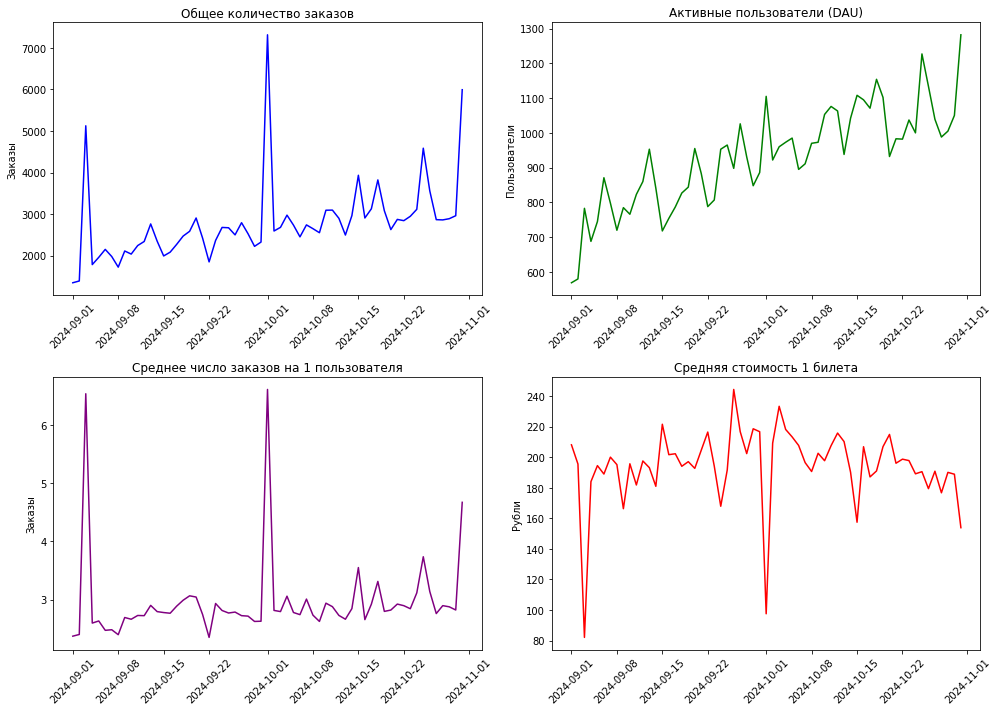

In [56]:
# Визуализируем данные в линейные графики -  4шт 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1  Общее количество заказов
axes[0,0].plot(summary.index, summary['заказы'], color='blue')
axes[0,0].set_title('Общее количество заказов')
axes[0,0].set_ylabel('Заказы')
axes[0,0].tick_params(axis='x', rotation=45)

# 2  DAU
axes[0,1].plot(summary.index, summary['DAU'], color='green')
axes[0,1].set_title('Активные пользователи (DAU)')
axes[0,1].set_ylabel('Пользователи')
axes[0,1].tick_params(axis='x', rotation=45)

# 3  Заказов на пользователя
axes[1,0].plot(summary.index, summary['заказов_на_пользователя'], color='purple')
axes[1,0].set_title('Среднее число заказов на 1 пользователя')
axes[1,0].set_ylabel('Заказы')
axes[1,0].tick_params(axis='x', rotation=45)

# 4 Средняя стоимость билета
axes[1,1].plot(summary.index, summary['цена_билета'], color='red')
axes[1,1].set_title('Средняя стоимость 1 билета')
axes[1,1].set_ylabel('Рубли')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Показатели активности осенью: 

    - заказы увеличились в 2 раза,
    
    - активные пользователи выросли на 60%
    
    - средняя стоимость билета снизилась до с 208 руб - 188 рублей

In [57]:
# Изучаем недельную цикличность:
autumn_data['weekday'] = autumn_data['created_dt_msk'].dt.dayofweek

# Фильтруем будни от выходных:
autumn_data['day_type'] = autumn_data['weekday'].apply(lambda x: 'будни' if x < 5 else 'выходные')

# Присваиваем дням имя:
days_name = {0:'понедельник', 1:'вторник', 2:'среда', 3:'четверг', 4:'пятница', 5:'суббота', 6:'воскресенье'}
autumn_data['days_name'] = autumn_data['weekday'].map(days_name)

# Считаем заказы по дням недели:
orders_by_day = autumn_data.groupby('days_name')['order_id'].count()
print(orders_by_day)

days_name
воскресенье    19580
вторник        31739
понедельник    21715
пятница        25091
среда          23129
суббота        21548
четверг        27395
Name: order_id, dtype: int64


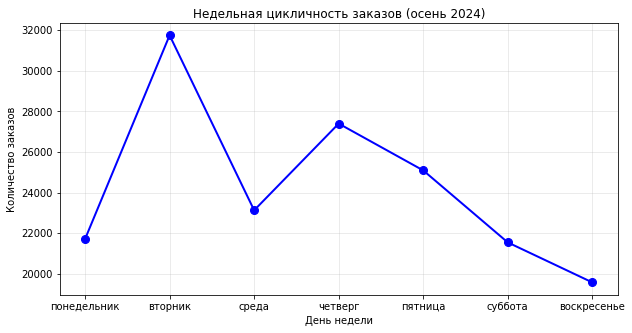

In [58]:
# Сортируем дни недели в правильном порядке
week_order = ['понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье']
orders_by_day_sorted = orders_by_day.reindex(week_order)

# Линейный график
plt.figure(figsize=(10, 5))
plt.plot(orders_by_day_sorted.index, orders_by_day_sorted.values, marker='o', linewidth=2, markersize=8, color='blue')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.title('Недельная цикличность заказов (осень 2024)')
plt.grid(True, alpha=0.3)
plt.show()

Самый активный день - вторник 31 739 заказов.

Самый неактивный день - воскресенье 19 580 заказов. 

В будни активность выше, чем в выходные.

 ### 3.3. Популярные события и партнёры

In [59]:
# 1 Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов. 
region_stats = final_tickets_orders_df.merge(
final_tickets_events_df[['event_id','region_name']],on= 'event_id'
).groupby('region_name').agg(
мероприятий = ('event_id','nunique'),
заказов = ('order_id','count')
).sort_values('мероприятий',ascending=False)

# Проверяем результат:
print(region_stats)

                          мероприятий  заказов
region_name                                   
Каменевский регион               5983    91058
Североярская область             3814    44049
Широковская область              1233    16457
Светополянский округ             1075     7607
Речиновская область               702     6293
...                               ...      ...
Теплоозёрский округ                 2        7
Сосноводолинская область            2       10
Лесноярский край                    2       19
Светолесский край                   2       24
Верхозёрский край                   2       11

[81 rows x 2 columns]


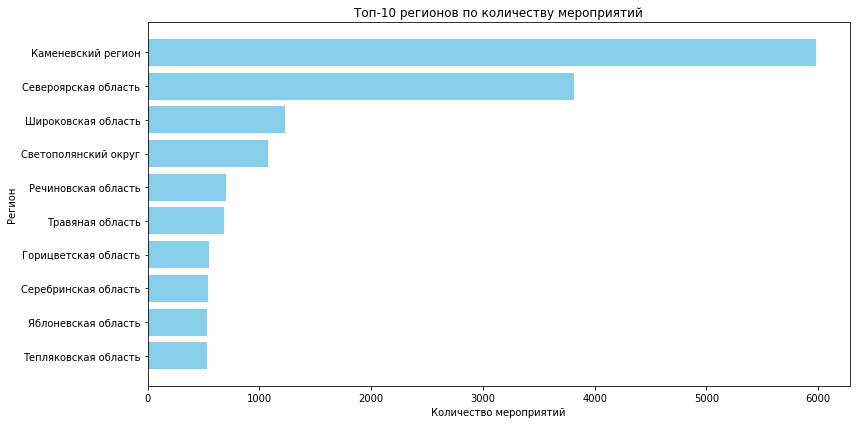

In [60]:
# топ-10 регионов
top_regions = region_stats.head(10)

# Горизонтальная столбчатая диаграмма
plt.figure(figsize=(12, 6))
plt.barh(top_regions.index, top_regions['мероприятий'], color='skyblue')
plt.xlabel('Количество мероприятий')
plt.ylabel('Регион')
plt.title('Топ-10 регионов по количеству мероприятий')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

Наибольшее разнообразие мероприятий наблюдается в:
- `Каменевском регионе ` - 5 983 
- `Североярской области` - 3 814 
- `Широковской области` - 1 233

Эти же регионы лидируют по колличеству заказов.

In [61]:
# 2 Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов.
partners = final_tickets_orders_df.groupby('service_name').agg(
мероприятий = ('event_id','nunique'),
заказов = ('order_id','count'),
выручка = ('revenue','sum')
).sort_values('заказов',ascending=False)

# Проверяем результат:
print(partners.head())

                    мероприятий  заказов     выручка
service_name                                        
Билеты без проблем         4263    63709  28881298.0
Лови билет!                4884    41126  17665574.0
Билеты в руки              3544    40364  13387966.0
Мой билет                  1310    34843  41353740.0
Облачко                    2348    26642  21644068.0


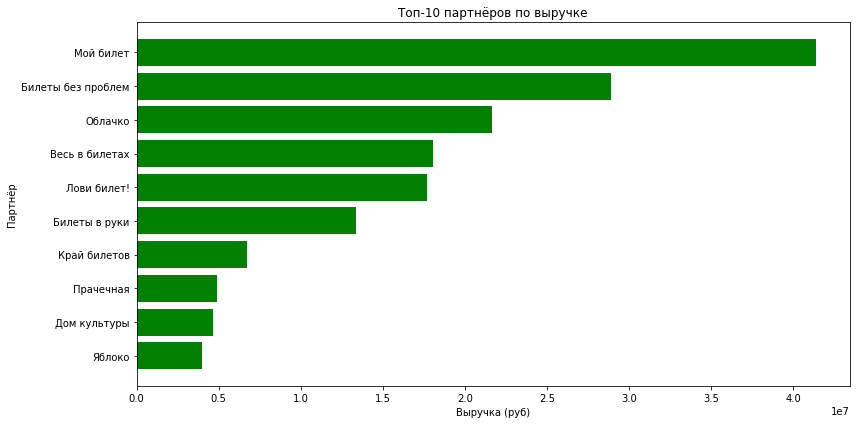

In [62]:
# Сортируем по выручке
top_partners_revenue = partners.sort_values('выручка', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_partners_revenue.index, top_partners_revenue['выручка'], color='green')
plt.xlabel('Выручка (руб)')
plt.ylabel('Партнёр')
plt.title('Топ-10 партнёров по выручке')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

`Лови билет! ` - лидер по колличеству мероприятий (4 884)

`Билеты без проблем` - лидер по колличеству заказов (63 709)

`Мой билет` - лидер по выручке (41 353 740 руб)



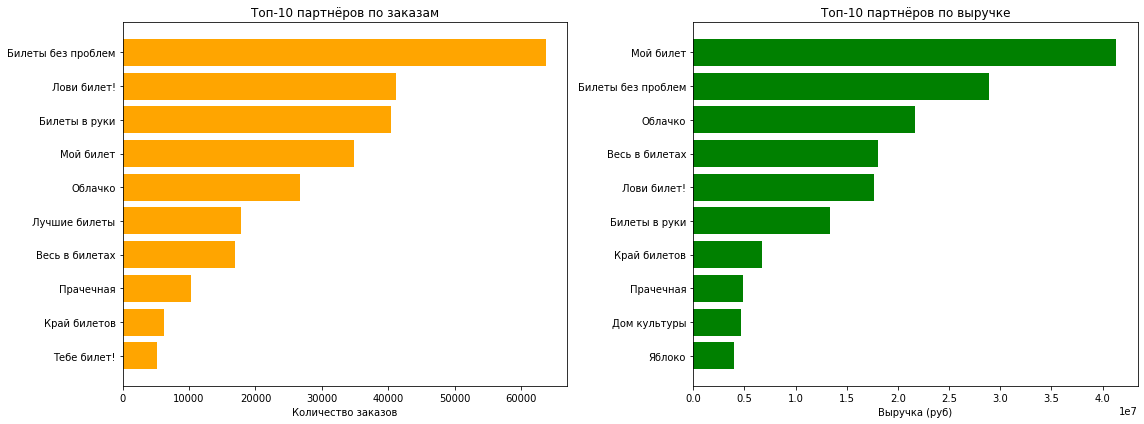

In [65]:
top_partners = partners.head(10) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#  Заказы
ax1.barh(top_partners.index, top_partners['заказов'], color='orange')
ax1.set_xlabel('Количество заказов')
ax1.set_title('Топ-10 партнёров по заказам')
ax1.invert_yaxis()

#  Выручка
top_partners_revenue = partners.sort_values('выручка', ascending=False).head(10)
ax2.barh(top_partners_revenue.index, top_partners_revenue['выручка'], color='green')
ax2.set_xlabel('Выручка (руб)')
ax2.set_title('Топ-10 партнёров по выручке')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

Среди регионов явный лидер - `Каменевский регион` (5983 - мероприятий и 91058 заказов)

Среди партнеров лидерами являются: 

`Лови билет!` - по колличеству мероприятий (4 884), 

`Билеты без проблем` - по колличеству заказов (63 709),

`Мой билет` - лидер по выручке (41 353 740 руб)


## 4. Статистический анализ данных

**Гипотеза №1:** "Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств."

`H0` - количество заказов у пользователей больше,использующих станционарное устройство.

`H1` - количество заказов у пользователей больше,использующих мобильное приложение.

In [ ]:
# Мобильные устройства:
mobile_orders= final_tickets_orders_df[final_tickets_orders_df['device_type_canonical'] == 'mobile'].groupby('user_id')['order_id'].count()
# Стационарные устройства :
desktop_orders = final_tickets_orders_df[final_tickets_orders_df['device_type_canonical'] == 'desktop'].groupby('user_id')['order_id'].count()

metric_a = mobile_orders
metric_b = desktop_orders

# Применяем t-тест Уэлча
stat_welsh_ttest, p_value_welsh_ttest = ttest_ind(
    metric_a,
    metric_b,
    equal_var=False,
    alternative='greater' # Альтернативная гипотеза, которую проверяем: mu_а > mu_b
)

alpha = 0.05
if p_value_welsh_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welsh_ttest, 2)}')
    print ('Нулевая гипотеза находит подтверждение! Выборочные средние в группах А и В равны')
else:
    print(f'p-value теста Уэлча ={round(p_value_welsh_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах А и В не равны, и в группе В больше')



Нулевая гипотеза отвергается,следовательно у пользователей, использующих мобильное приложение заказов больше.

**Гипотеза №2:** "Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств."

`H0` - среднее время выше,у пользователей,использующих стационарное устройство.

`H1` - среднее время выше, у пользователей,использующих мобильное приложение.

In [ ]:
# Считаем среднее время между заказами:
autumn_data = final_tickets_orders_df[final_tickets_orders_df['month'].isin([9, 10])].sort_values(['user_id', 'created_ts_msk'])
autumn_data['time_diff'] = autumn_data.groupby('user_id')['created_ts_msk'].diff().dt.total_seconds() / 3600

# Отбираем мобильные и декстопные версии:
mobile_time = autumn_data[(autumn_data['device_type_canonical'] == 'mobile') & (autumn_data['time_diff'].notna())]['time_diff']
desktop_time = autumn_data[(autumn_data['device_type_canonical'] == 'desktop') & (autumn_data['time_diff'].notna())]['time_diff']

metric_a = mobile_time
metric_b = desktop_time

# Применяем t-тест Уэлча
stat_welsh_ttest, p_value_welsh_ttest = ttest_ind(
    metric_a,
    metric_b,
    equal_var=False,
    alternative='greater' # Альтернативная гипотеза, которую проверяем: mu_а > mu_b
)

alpha = 0.05
if p_value_welsh_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welsh_ttest, 2)}')
    print ('Нулевая гипотеза находит подтверждение! Выборочные средние в группах А и В равны')
else:
    print(f'p-value теста Уэлча ={round(p_value_welsh_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах А и В не равны, и в группе А больше')

Нулевая гипотеза отвергается, среднее время выше, у пользователей,использующих мобильное приложение.

## 5  Общий вывод и рекомендации

В ходе выполнения проекта мы проанализировали 290 849 заказов билетов на период с июня-октябрь 2024 года.

Наиболее востребованные мероприятия:

    - Наиболее дорогие мероприятия (с высокой выручкой за билет): концерты, ёлки и стендап.
    - Популярность мероприятий осенью: Стандап к осени вырос на 10% и выставки на 5%.Билеты подешевели везде,кроме стендапов и выставок.  
    -Средняя стоимость билета снизилась по всем типам мероприятий, кроме стендапа +10% и выставок +5% 
    
Пользовательская актвиность:

    - мобильные устройства - главный канал для продаж
    - Пик активности вторник и четверг,спад -воскресенье
    
Лидеры по числу заказов и выручке с продажи билетов:
    
    1. Каменевский регион (5983 мероприятий и 91058 заказов)
    2. Североярская область (3814 мероприятий  и  44049 заказов)
    3. Широковская область (1233 мероприятий  и 16457 заказов)
    
Партнеры:
    1. Лови билет! - лидер по колличеству мероприятий (4 884)
    2. Билеты без проблем - лидер по колличеству заказов (63 709)
    3. Мой билет - лидер по выручке (41 353 740 руб)
    
Пользователи мобильных устройств активнее пользователей стационарных устройств. 

**Рекомендации:**
 1. Сделать акцент на мобильную платформу.
 2. Усилить продвижение концертов и выставок.
 3. Запускать акции в начале недели(вторник-четверг).
 4. Сфокусироваться на партнерах:  Мой билет и Билеты без проблем.
 5. Обратить внимание на падение выручки за билет осенью.
